In [1]:
"""
Notebook 03: Region of Interest (ROI) Extraction
=================================================
Convert to notebook with: jupytext --to notebook notebooks/03_roi.py

Covers:
- Phase 5: Slot Extraction & Masking
"""

'\nNotebook 03: Region of Interest (ROI) Extraction\n=================================================\nConvert to notebook with: jupytext --to notebook notebooks/03_roi.py\n\nCovers:\n- Phase 5: Slot Extraction & Masking\n'

# Notebook 03: Region of Interest (ROI) Extraction

**Course:** Digital Image Processing
**Project:** Automatic Parking Occupancy Estimation

---

## Objectives
1. Transform slot polygon coordinates from original to BEV
2. Extract bounding box image patches for each slot
3. Create full polygon masks to exclude neighbouring cars
4. Create eroded "core" masks to focus strictly on the vehicle body
5. Save the transformed slot definitions to `config/slots.json`

## 1. Setup & Imports

In [2]:
import sys, os

# Change working directory to project root so relative paths work
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.insert(0, os.path.abspath('.'))

import cv2
import numpy as np
import matplotlib
%matplotlib inline
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

from src.utils import load_config, print_separator
from src.io_utils import list_frames, parse_pklot_xml
from src.geometry import load_homography, transform_points, warp_perspective
from src.roi import (
    extract_slot_image, create_eroded_core_mask,
    draw_slots_on_image, save_slots_json, load_slots_json
)
from src.visualize import show_and_save_fig

np.random.seed(42)
config = load_config('config/config.yaml')

# Load Homography
HOMOGRAPHY_PATH = 'config/homography.npz'
if os.path.exists(HOMOGRAPHY_PATH):
    hdata = load_homography(HOMOGRAPHY_PATH)
    H = hdata['H']
    output_size = hdata['output_size']
    px_per_m = hdata.get('px_per_metre', 1.0)
    print(f"Loaded homography! Scale: {px_per_m:.1f} px/m")
else:
    print("ERROR: Run Notebook 02 first to generate homography.npz")
    H = None

Loaded homography! Scale: 14.4 px/m


## 2. Load Frame & Warp to BEV

In [3]:
DATA_ROOT = 'data/raw/PKLot'
PRIMARY_LOT = 'parking2'  # Match tar lowercase name for UFPR05
LOT_PATH = os.path.join(DATA_ROOT, PRIMARY_LOT)

frames = list_frames(LOT_PATH)
if not frames or H is None:
    print("ERROR: missing data or homography")
else:
    # Use a sunny frame to test
    sunny_frames = [f for f in frames if f['weather'] == 'sunny']
    frame_info = sunny_frames[len(sunny_frames)//2] if sunny_frames else frames[0]
    
    img = cv2.imread(frame_info['image_path'])
    bev = warp_perspective(img, H, output_size)
    print(f"Loaded {frame_info['image_path']}")

Loaded data/raw/PKLot/parking2/sunny/2012-09-20/2012-09-20_14_04_35.jpg


## 3. Transform Slot Polygons to BEV

We take the original coordinates from the XML and push them through `H`.

In [4]:
if frames and H is not None:
    original_slots = parse_pklot_xml(frame_info['xml_path'])
    
    bev_slots = {}
    for slot in original_slots:
        # Transform the 4 corner points
        bev_pts = transform_points(slot['points'], H)
        bev_slots[slot['id']] = bev_pts
        
    print(f"Transformed {len(bev_slots)} slots to BEV coordinates.")

Transformed 100 slots to BEV coordinates.


## 4. The "Overlap Problem" and Core Masks

### The Problem
Even in BEV, cars slightly overlap into adjacent slots due to their height
(especially large SUVs/trucks). If we just take a rectangular bounding box,
we will include pieces of neighbouring cars, confusing our classifier.

### The Solution
1. **Bounding Box Patch:** Extract a rectangular crop to work on (faster).
2. **Full Polygon Mask:** Zero out anything outside the true slot polygon.
3. **Eroded Core Mask:** Shrink the polygon inwards by a few pixels.
   This ignores the boundaries where neighbour overlap usually occurs.

We will construct a three-panel visualization to show this.

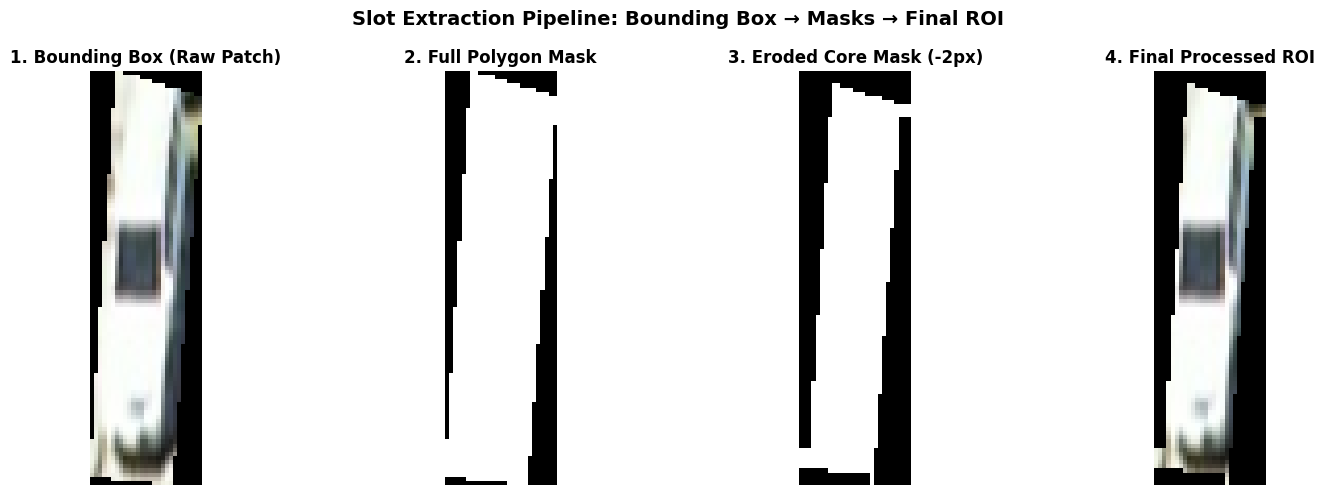

Saved: outputs/screenshots/06_mask_extraction.png


In [5]:
if frames and H is not None:
    # Pick a random slot to demonstrate
    slot_id = list(bev_slots.keys())[5]
    polygon = bev_slots[slot_id]
    
    # 1. Extract bounding box patch & full mask
    patch, bbox, full_mask = extract_slot_image(bev, polygon)
    
    # 2. Create eroded core mask
    # 3px in BEV corresponds to ~5cm at our scale (depending on px/m)
    erosion_px = max(2, int(0.15 * px_per_m)) # ~15cm erosion
    core_mask = create_eroded_core_mask(full_mask, erosion_px=erosion_px)
    
    # 3. Apply masks for visualization
    masked_full = cv2.bitwise_and(patch, patch, mask=full_mask)
    masked_core = cv2.bitwise_and(patch, patch, mask=core_mask)
    
    # Visualization
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    
    axes[0].imshow(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
    axes[0].set_title('1. Bounding Box (Raw Patch)', fontweight='bold')
    
    axes[1].imshow(full_mask, cmap='gray')
    axes[1].set_title('2. Full Polygon Mask', fontweight='bold')
    
    axes[2].imshow(core_mask, cmap='gray')
    axes[2].set_title(f'3. Eroded Core Mask (-{erosion_px}px)', fontweight='bold')
    
    axes[3].imshow(cv2.cvtColor(masked_core, cv2.COLOR_BGR2RGB))
    axes[3].set_title('4. Final Processed ROI', fontweight='bold')
    
    for ax in axes:
        ax.axis('off')
        
    show_and_save_fig(fig,
                     'Slot Extraction Pipeline: Bounding Box → Masks → Final ROI',
                     '06_mask_extraction.png')

## 5. Visualize All ROIs
Draw the full layout to verify the ROIs are correct.

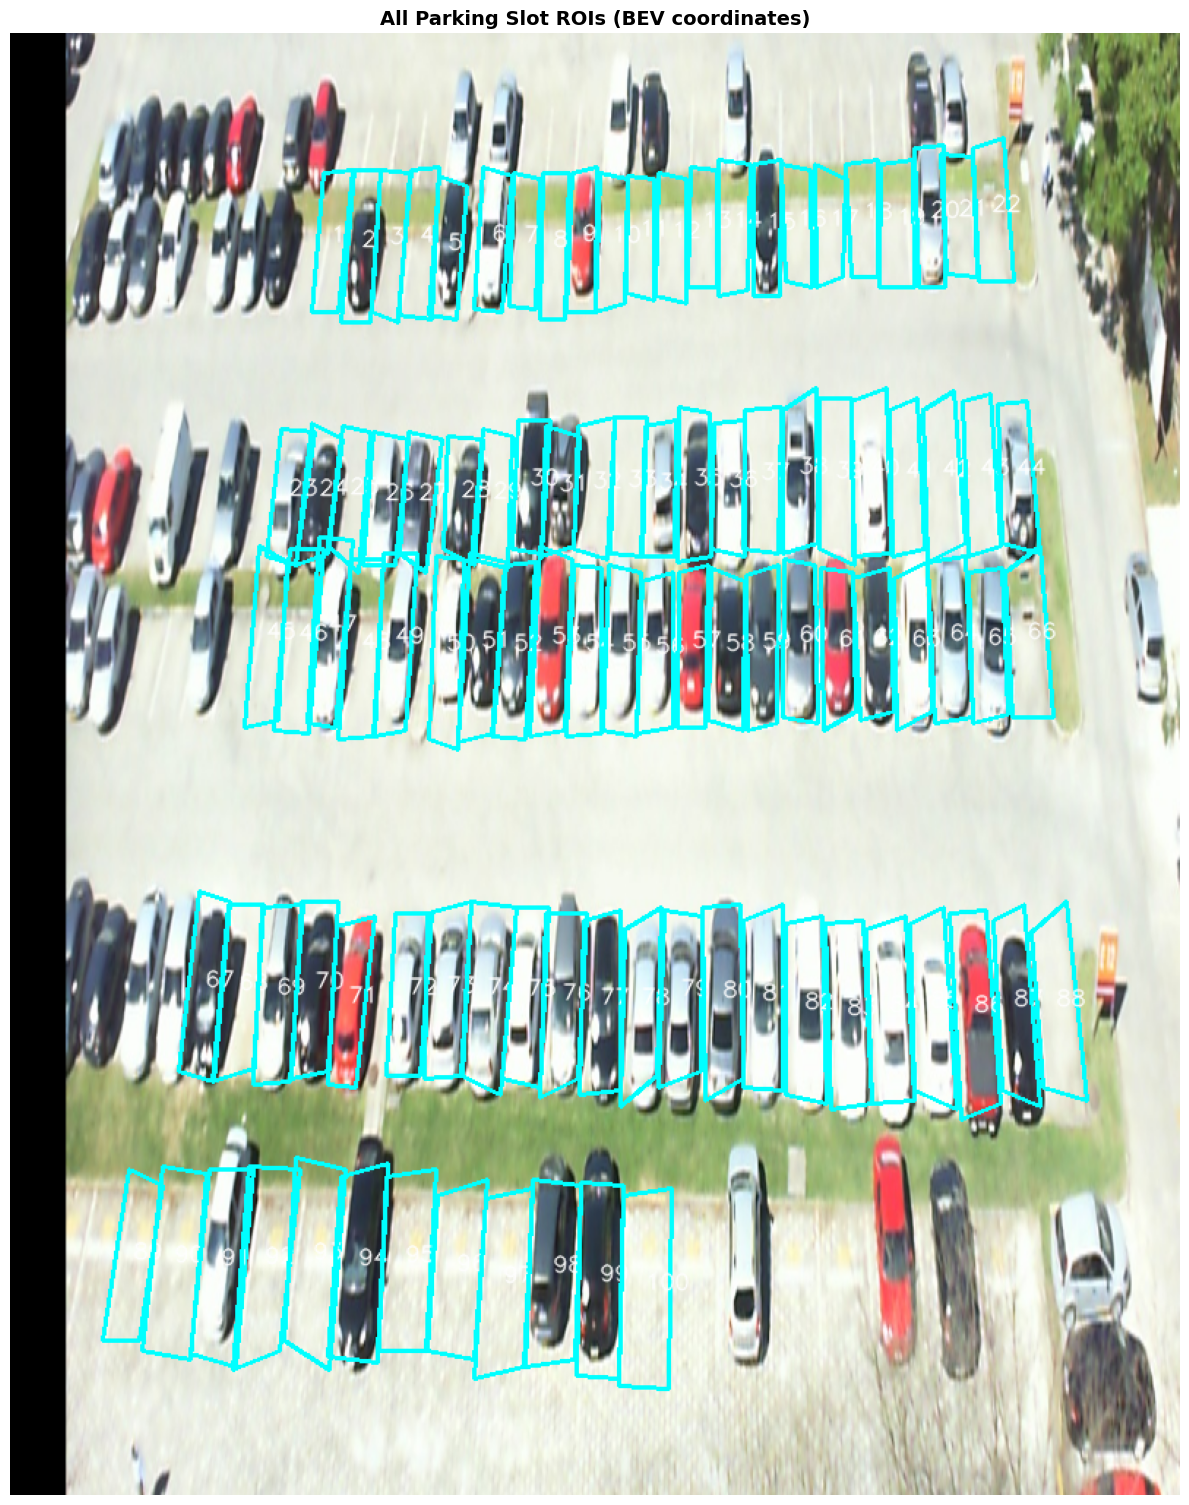

Saved: outputs/screenshots/07_all_rois.png


In [6]:
if frames and H is not None:
    # Draw all slot ROIs on the BEV image
    roi_vis = draw_slots_on_image(bev, bev_slots, thickness=2)
    
    show_and_save_fig(roi_vis,
                     'All Parking Slot ROIs (BEV coordinates)',
                     '07_all_rois.png', figsize=(12, 16))

## 6. Save Slot Definitions to Config

We only need to compute these BEV coordinates once for the entire project.
We'll save them to `config/slots.json`.

In [7]:
if frames and H is not None:
    SLOTS_PATH = 'config/slots.json'
    
    # Save
    save_slots_json(SLOTS_PATH, bev_slots)
    print(f"Saved {len(bev_slots)} slot definitions to {SLOTS_PATH}")
    
    # Test load
    loaded_slots = load_slots_json(SLOTS_PATH)
    print(f"Successfully re-loaded {len(loaded_slots)} slots!")

Saved 100 slot definitions to config/slots.json
Successfully re-loaded 100 slots!


## Phase Summary

### What we accomplished
1. Transformed original slot polygons into BEV coordinates
2. Built extraction logic for bounding box + binary mask
3. Implemented the **eroded core mask** to solve adjacent-car overlap
4. Visualized the ROI extraction pipeline
5. Saved canonical BEV slot coordinates to `config/slots.json`

### Key insights
- The eroded mask is a critical classical technique to isolate the signal.
- Without it, a white SUV parked next to an empty slot might cause the empty slot to look occupied.

### Notebook 04 — Image Preprocessing
With clean, masked, BEV image patches for every slot, the next step is
preprocessing (Phase 6) and segmentation (Phase 7).